# 02 — Pré-processamento e geração dos datasets
**Classificação de gênero musical — GTZAN / CNN sobre espectrogramas Mel**

Este notebook transforma o áudio bruto nos arrays prontos para treino, cobrindo as duas
fontes de entrada que o projeto compara:

1. **librosa** — espectrogramas Mel de **3 s** gerados a partir dos `.wav` (caminho principal);
2. **imagem** — os PNGs prontos (`images_original`) redimensionados.

A divisão treino/validação/teste é herdada do split **por música** (definido em `src.data`),
de modo que segmentos de uma mesma música nunca vazam entre splits. Os arrays são salvos em
`data/processed/` e reaproveitados em execuções seguintes.

In [1]:
import sys
from pathlib import Path
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from src import config as C
from src import data, preprocess

%matplotlib inline
plt.rcParams["figure.dpi"] = 100
print("Forma de entrada da CNN (librosa):", C.INPUT_SHAPE)
print("Tamanho das imagens (PNG):", C.IMAGE_SIZE)
print("Diretório de saída:", C.PROCESSED_DIR)

Forma de entrada da CNN (librosa): (128, 130, 1)
Tamanho das imagens (PNG): (128, 128)
Diretório de saída: C:\Users\User\music-genre-classification\data\processed


## 1. Índice e divisão por música

Reconstruímos o índice (uma linha por música, sem o arquivo corrompido) e aplicamos a
divisão estratificada por gênero — exatamente a mesma semente da EDA, garantindo
reprodutibilidade.

In [2]:
index = data.split_tracks(data.build_track_index())
print("Músicas por split:")
print(index["split"].value_counts())
print("\nDistribuição por gênero e split:")
display(index.groupby(["genre", "split"]).size().unstack(fill_value=0)[["train", "val", "test"]])

Músicas por split:
split
train    699
val      150
test     150
Name: count, dtype: int64

Distribuição por gênero e split:


split,train,val,test
genre,,,
blues,70,15,15
classical,70,15,15
country,70,15,15
disco,70,15,15
hiphop,70,15,15
jazz,69,15,15
metal,70,15,15
pop,70,15,15
reggae,70,15,15


## 2. Caminho librosa — espectrogramas Mel de 3 s

Para cada música: carrega o áudio, divide em 10 segmentos de 3 s, calcula o espectrograma
Mel em dB, fixa a largura em `MEL_FRAMES` e normaliza para [0, 1]. Armazenado como
`float16` para economizar disco/memória. **Esta célula é a etapa pesada** (carrega ~999
áudios); ao reexecutar, usa o cache.

In [3]:
if preprocess.is_cached("mel"):
    print("Cache encontrado — carregando arrays Mel existentes.")
    mel = preprocess.load_dataset("mel")
else:
    print("Gerando espectrogramas Mel (pode levar alguns minutos)...")
    mel = preprocess.build_mel_dataset(index)
    preprocess.save_dataset(mel, "mel")
    print("Salvo em", C.PROCESSED_DIR)

for split, (X, y) in mel.items():
    mb = X.nbytes / 1e6
    print(f"{split:5s}: X={X.shape} dtype={X.dtype} ({mb:.0f} MB) | y={y.shape}")

Gerando espectrogramas Mel (pode levar alguns minutos)...


  [train] 100/699 tracks -> 1000 segments


  [train] 200/699 tracks -> 1997 segments


  [train] 300/699 tracks -> 2997 segments


  [train] 400/699 tracks -> 3996 segments


...

  [val] 100/150 tracks -> 999 segments


  [val] done: X=(1499, 128, 130, 1), y=(1499,)


  [test] 100/150 tracks -> 997 segments


  [test] done: X=(1497, 128, 130, 1), y=(1497,)


Salvo em C:\Users\User\music-genre-classification\data\processed
train: X=(6985, 128, 130, 1) dtype=float16 (232 MB) | y=(6985,)
val  : X=(1499, 128, 130, 1) dtype=float16 (50 MB) | y=(1499,)
test : X=(1497, 128, 130, 1) dtype=float16 (50 MB) | y=(1497,)


### 2.1 Verificação de sanidade

Conferimos que cada classe tem ~10× o número de músicas em segmentos e visualizamos alguns
espectrogramas já normalizados (entrada real da rede).

In [4]:
Xtr, ytr = mel["train"]
print("Segmentos de treino por classe:")
for i, g in C.IDX_TO_GENRE.items():
    print(f"  {g:10s}: {(ytr == i).sum()}")
print("Faixa de valores (deve ser ~[0,1]):", float(Xtr.min()), float(Xtr.max()))

Segmentos de treino por classe:
  blues     : 700
  classical : 699
  country   : 698
  disco     : 700
  hiphop    : 699
  jazz      : 690
  metal     : 700
  pop       : 700
  reggae    : 700
  rock      : 699


Faixa de valores (deve ser ~[0,1]): 0.0 1.0


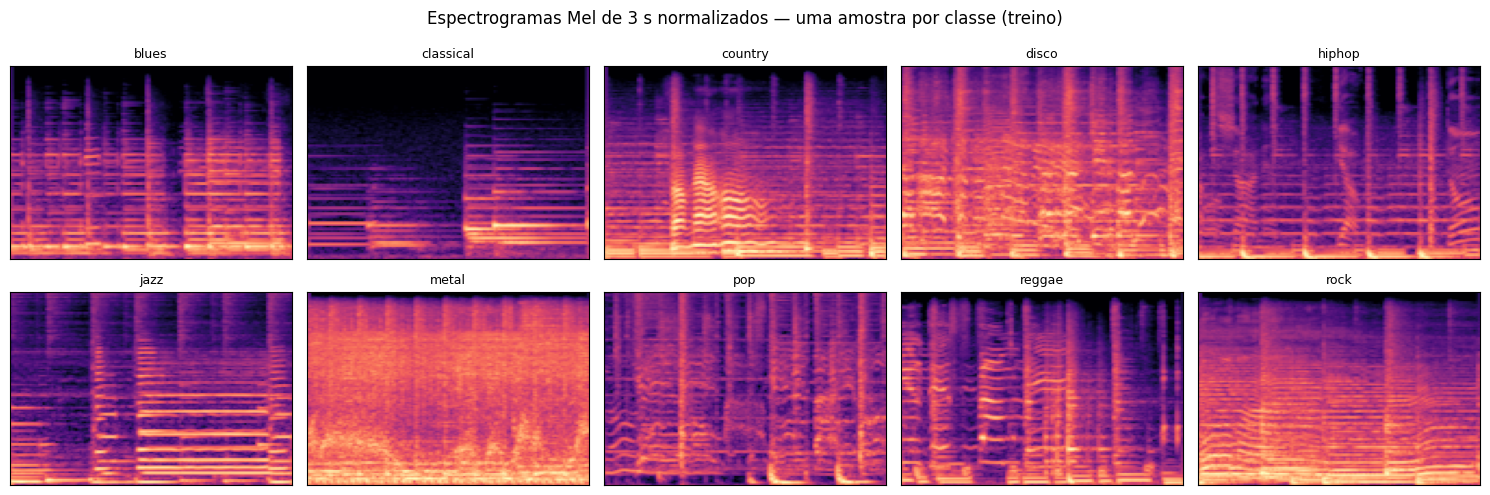

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(15, 5))
rng = np.random.default_rng(C.SEED)
for ax, i in zip(axes.ravel(), range(C.NUM_CLASSES)):
    idxs = np.where(ytr == i)[0]
    j = rng.choice(idxs)
    ax.imshow(Xtr[j, :, :, 0].astype(np.float32), origin="lower", aspect="auto", cmap="magma")
    ax.set_title(C.IDX_TO_GENRE[i], fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Espectrogramas Mel de 3 s normalizados — uma amostra por classe (treino)", fontsize=12)
plt.tight_layout(); plt.show()

## 3. Caminho imagem — PNGs prontos

Carregamos os espectrogramas PNG do dataset, convertendo para RGB e redimensionando para
`IMAGE_SIZE`. Servem como segunda fonte de entrada na comparação (clipe inteiro de 30 s).

In [6]:
if preprocess.is_cached("img"):
    print("Cache encontrado — carregando arrays de imagem existentes.")
    img = preprocess.load_dataset("img")
else:
    print("Carregando e redimensionando PNGs...")
    img = preprocess.build_image_dataset(index)
    preprocess.save_dataset(img, "img")
    print("Salvo em", C.PROCESSED_DIR)

for split, (X, y) in img.items():
    mb = X.nbytes / 1e6
    print(f"{split:5s}: X={X.shape} dtype={X.dtype} ({mb:.0f} MB) | y={y.shape}")

Carregando e redimensionando PNGs...


  [train] images: X=(699, 128, 128, 3), y=(699,)


  [val] images: X=(150, 128, 128, 3), y=(150,)


  [test] images: X=(150, 128, 128, 3), y=(150,)


Salvo em C:\Users\User\music-genre-classification\data\processed
train: X=(699, 128, 128, 3) dtype=float32 (137 MB) | y=(699,)
val  : X=(150, 128, 128, 3) dtype=float32 (29 MB) | y=(150,)
test : X=(150, 128, 128, 3) dtype=float32 (29 MB) | y=(150,)


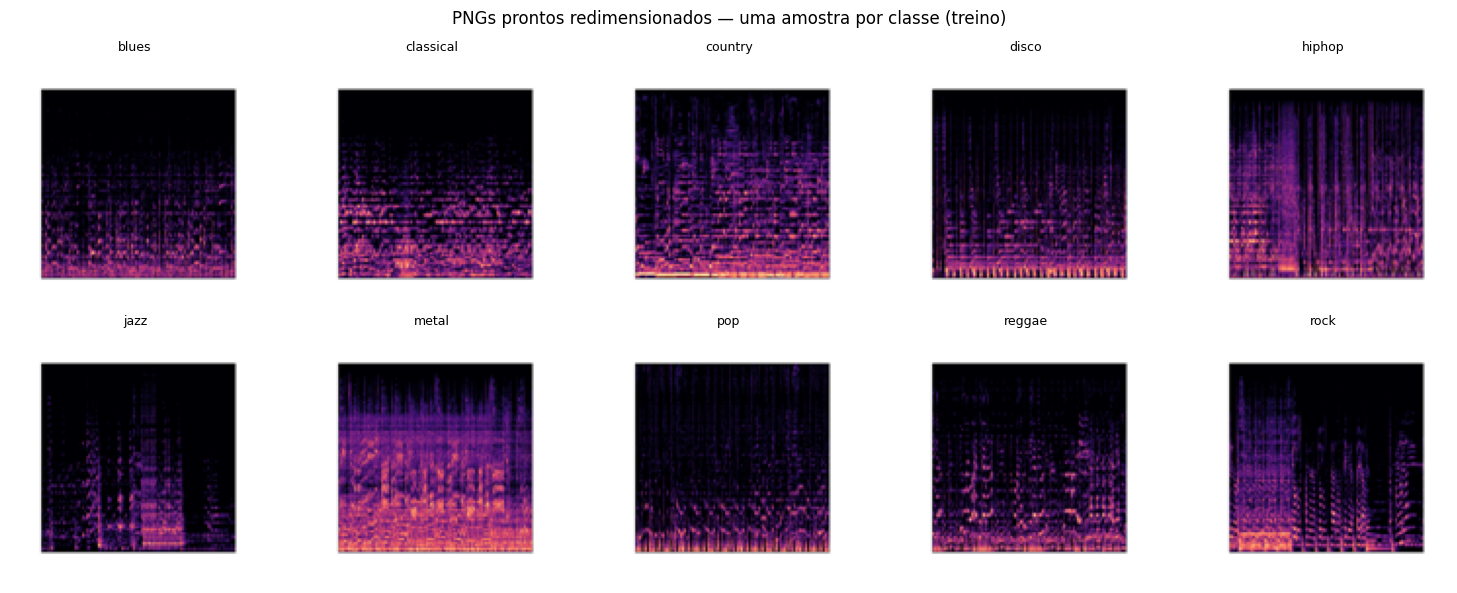

In [7]:
Xi, yi = img["train"]
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, i in zip(axes.ravel(), range(C.NUM_CLASSES)):
    idxs = np.where(yi == i)[0]
    ax.imshow(Xi[idxs[0]])
    ax.set_title(C.IDX_TO_GENRE[i], fontsize=9)
    ax.axis("off")
plt.suptitle("PNGs prontos redimensionados — uma amostra por classe (treino)", fontsize=12)
plt.tight_layout(); plt.show()

## 4. Resumo

Os dois datasets estão prontos e em cache em `data/processed/`:

- **`mel_*`** — espectrogramas Mel de 3 s (librosa), entrada principal da CNN.
- **`img_*`** — PNGs prontos redimensionados, para o experimento de comparação.

Ambos respeitam a divisão por música (sem vazamento). Os arrays são carregados em segundos
nos próximos notebooks via `preprocess.load_dataset(...)`.

**Próximo passo:** `03_baseline_cnn.ipynb` — treinar a CNN baseline sobre os espectrogramas
Mel de 3 s e estabelecer a primeira referência de acurácia e F1 macro.